# LLR Comparison: Base ESM2 vs Per-Pfam LoRA-Finetuned

Loads the per-pfam LLR comparison payloads produced by
`ESM_domainome_llr_pfam_compare_dictall.ipynb` (one
`llr_comparison_all.pkl.gz` per pfam under
`gs://{bucket}/ESM2/ft_per_pfam/global_finetune/{pfam_id}/`), then for every
(pfam model × domain) pair computes Spearman ρ of measured fitness vs base
and finetuned LLR. Results are aggregated into a single `corr_df` with a
`model` column identifying which pfam-finetuned LoRA produced each row.


In [1]:
import os
import io
import gzip
import json
import pickle
import warnings
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from matplotlib.patches import Patch
from tqdm import tqdm
from dotenv import load_dotenv
from transformers import EsmForMaskedLM, EsmTokenizer
from peft import LoraConfig, get_peft_model
from google.cloud import storage

warnings.filterwarnings("ignore")
logging.getLogger("transformers").setLevel(logging.ERROR)

/opt/anaconda3/envs/MachLearn/lib/python3.12/site-packages/seaborn/_statistics.py:32: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.6)
  from scipy.stats import gaussian_kde
/opt/anaconda3/envs/MachLearn/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ── Constants (must match training run) ──────────────────────────────────────

AA_ORDER         = ['L', 'A', 'G', 'V', 'S', 'E', 'R', 'T', 'I', 'D',
                    'P', 'K', 'Q', 'N', 'F', 'Y', 'M', 'H', 'W', 'C']
FITNESS_AA_ORDER = list("ACDEFGHIKLMNPQRSTVWY")
MODEL_NAME       = "facebook/esm2_t33_650M_UR50D"
MAX_LEN          = 1022
LORA_DROPOUT     = 0.1

# ── Local + GCS layout (must match per-pfam compare run) ─────────────────────

OUTPUT_DIR    = "finetuned_models_v2"
RUN_ID_PREFIX = "global_finetune"   # matches per-pfam compare notebook
os.makedirs(OUTPUT_DIR, exist_ok=True)

GCS_PROJECT           = "plm-study-484223"
GCS_BUCKET            = "domainome-data"
GCS_DOMAIN_DATA_BLOB  = "ESM2/dict_fitness.pkl.gz"
GCS_FULL_PROTEIN_BLOB = "ESM2/dict_domainome_uniprot_new.pkl.gz"
GCS_OUTPUT_PREFIX     = "ESM2/ft_per_pfam/"   # must end with /

LLR_OUTPUT_NAME = "llr_comparison_all.pkl.gz"


def pfam_paths(pfam_id):
    """Resolve per-pfam local + GCS paths for the per-pfam compare payload."""
    run_id  = f"{RUN_ID_PREFIX}/{pfam_id}"
    run_dir = os.path.join(OUTPUT_DIR, run_id)
    return {
        "run_id":    run_id,
        "run_dir":   run_dir,
        "llr_local": os.path.join(run_dir, LLR_OUTPUT_NAME),
        "gcs_llr":   f"{GCS_OUTPUT_PREFIX}{run_id}/{LLR_OUTPUT_NAME}",
    }


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [3]:
# ── GCS Helpers ──────────────────────────────────────────────────────────────
load_dotenv()
cred_path = os.getenv('GOOGLE_APPLICATION_CREDENTIALS')

os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = cred_path

# _gcs_client = storage.Client(project=GCS_PROJECT) if GCS_PROJECT else storage.Client()
_gcs_client = storage.Client()
_gcs_bucket = _gcs_client.bucket(GCS_BUCKET)


def gcs_download_pickle_gz(blob):
    data = blob.download_as_bytes()
    with gzip.GzipFile(fileobj=io.BytesIO(data), mode="rb") as gz:
        return pickle.load(gz)


def gcs_download_to_file(blob_path, local_path):
    blob = _gcs_bucket.blob(blob_path)
    os.makedirs(os.path.dirname(local_path), exist_ok=True)
    blob.download_to_filename(local_path)
    return local_path


def gcs_upload_file(blob_path, local_path, content_type="application/octet-stream"):
    blob = _gcs_bucket.blob(blob_path)
    blob.upload_from_filename(local_path, content_type=content_type)

In [4]:
# ── Helpers (mirrored from training notebook) ────────────────────────────────

def truncate_to_domain(sequence, domain_start, domain_end, max_len=MAX_LEN):
    seq_len    = len(sequence)
    domain_mid = (domain_start + domain_end) // 2
    half       = max_len // 2
    start      = max(0, domain_mid - 1 - half)
    end        = start + max_len
    if end > seq_len:
        end   = seq_len
        start = max(0, end - max_len)
    return sequence[start:end], start


def get_LLR_scores(sequence, model, tokenizer, device):
    seq_list  = list(sequence)
    tokenized = tokenizer(sequence, padding=False, truncation=True,
                          max_length=1024, return_tensors="pt")
    input_ids = tokenized["input_ids"].to(device)

    logits    = model(input_ids).logits
    log_probs = torch.log_softmax(logits, dim=-1)
    wt_logits = log_probs[:, 1:-1, :].squeeze(0)

    wt_logits_df = pd.DataFrame(
        wt_logits[:, 4:24].cpu().detach().numpy(),
        columns=AA_ORDER,
        index=[f"{aa} {i+1}" for i, aa in enumerate(seq_list)]
    ).T

    wt_norm = np.diag(wt_logits_df.loc[[c.split(" ")[0] for c in wt_logits_df.columns]])
    LLR     = wt_logits_df - wt_norm
    return LLR, wt_logits, seq_list


def fitness_matrix_to_rows(fitness, dom_seq, position_offset=0):
    rows = []
    for i, wt_aa in enumerate(dom_seq):
        if i >= len(fitness):
            break
        row = fitness[i]
        for j, mut_aa in enumerate(FITNESS_AA_ORDER):
            if j >= len(row):
                continue
            val = row[j]
            if val is None:
                continue
            try:
                fval = float(val)
            except (TypeError, ValueError):
                continue
            if np.isnan(fval):
                continue
            if mut_aa == wt_aa:
                continue
            rows.append({
                "position":           position_offset + i + 1,
                "wt_aa":              wt_aa,
                "mut_aa":             mut_aa,
                "normalized_fitness": fval,
            })
    return rows


def build_lora_model(lora_r, lora_alpha):
    """Rebuild the exact ESM2 + LoRA architecture used during training."""
    model       = EsmForMaskedLM.from_pretrained(MODEL_NAME)
    lora_config = LoraConfig(
        task_type      = "FEATURE_EXTRACTION",
        r              = lora_r,
        lora_alpha     = lora_alpha,
        target_modules = ["query", "key", "value", "output.dense"],
        lora_dropout   = LORA_DROPOUT,
    )
    model = get_peft_model(model, lora_config)
    return model

In [5]:
# ── Discover pfams + load all per-pfam payloads (skip recompute) ─────────────
#
# Lists every `llr_comparison_all.pkl.gz` under
# gs://{GCS_BUCKET}/{GCS_OUTPUT_PREFIX}{RUN_ID_PREFIX}/{pfam_id}/, downloads
# any that aren't cached locally, and loads them into
# `pfam_payloads[pfam_id]`. Each payload's `domains` dict has the same shape
# as the single-model run: {domain_id: {sequence, base_llr, ft_llr, ...}}.

_run_prefix = f"{GCS_OUTPUT_PREFIX}{RUN_ID_PREFIX}/"

PFAM_IDS = sorted({
    blob.name[len(_run_prefix):].split("/", 1)[0]
    for blob in _gcs_client.list_blobs(GCS_BUCKET, prefix=_run_prefix)
    if blob.name.endswith(f"/{LLR_OUTPUT_NAME}")
})

print(f"Found {len(PFAM_IDS)} pfams under gs://{GCS_BUCKET}/{_run_prefix}")
print(PFAM_IDS[:10], "..." if len(PFAM_IDS) > 10 else "")

pfam_payloads = {}

for pfam_id in tqdm(PFAM_IDS, desc="Load pfam payloads"):
    paths = pfam_paths(pfam_id)
    if not os.path.exists(paths["llr_local"]):
        try:
            gcs_download_to_file(paths["gcs_llr"], paths["llr_local"])
        except Exception as exc:
            tqdm.write(f"[{pfam_id}] download failed: {exc}")
            continue
    with gzip.open(paths["llr_local"], "rb") as gz:
        pfam_payloads[pfam_id] = pickle.load(gz)

print(f"Loaded payloads for {len(pfam_payloads)} pfams")
if pfam_payloads:
    sample_pfam    = next(iter(pfam_payloads))
    sample_payload = pfam_payloads[sample_pfam]
    sample_id      = next(iter(sample_payload["domains"]))
    sample         = sample_payload["domains"][sample_id]
    print(f"Sample pfam={sample_pfam} domain={sample_id} "
          f"seq_len={len(sample['sequence'])} "
          f"base_llr={sample['base_llr'].shape} "
          f"ft_llr={sample['ft_llr'].shape}")

Found 126 pfams under gs://domainome-data/ESM2/ft_per_pfam/global_finetune/
['PF00010', 'PF00013', 'PF00018', 'PF00030', 'PF00035', 'PF00046', 'PF00096', 'PF00105', 'PF00130', 'PF00157'] ...


Load pfam payloads: 100%|██████████| 126/126 [1:14:28<00:00, 35.47s/it]

Loaded payloads for 126 pfams
Sample pfam=PF00010 domain=A0A2R8Y422_PF00240_2 seq_len=70 base_llr=(20, 70) ft_llr=(20, 70)


In [6]:
# ── Spearman: fitness vs (base LLR, finetuned LLR) per (model × domain) ─────
#
# For every pfam-finetuned model in `pfam_payloads` and every domain it
# scored, line up each measured (position, mut_aa) fitness value with the
# corresponding entry in that model's base and finetuned LLR matrices and
# compute Spearman ρ separately for base and ft. The resulting `corr_df`
# carries a `model` column equal to the pfam id of the LoRA-finetuned model
# whose ft_llr produced that row.

from scipy.stats import spearmanr

try:
    fitness_dict
except NameError:
    print(f"Loading fitness dict from gs://{GCS_BUCKET}/{GCS_DOMAIN_DATA_BLOB}")
    fitness_dict = gcs_download_pickle_gz(_gcs_bucket.blob(GCS_DOMAIN_DATA_BLOB))
    print(f"Loaded {len(fitness_dict)} fitness entries")

aa_to_row = {aa: i for i, aa in enumerate(AA_ORDER)}

per_domain_rows = []
skipped_no_match = 0
skipped_too_few  = 0

for pfam_model_id, payload in tqdm(pfam_payloads.items(), desc="Pfam models"):
    for domain_id, entry in payload["domains"].items():
        fd = fitness_dict.get(domain_id)
        if not isinstance(fd, dict):
            continue
        fitness = fd.get("fitness")
        dom_seq = fd.get("dom_seq")
        if fitness is None or dom_seq is None:
            continue

        sequence = entry["sequence"]
        base_llr = entry["base_llr"]
        ft_llr   = entry["ft_llr"]
        n_pos    = base_llr.shape[1]

        idx_in_seq = sequence.find(dom_seq)
        if idx_in_seq < 0:
            skipped_no_match += 1
            continue

        fits, base_vals, ft_vals = [], [], []
        for i, wt_aa in enumerate(dom_seq):
            col = idx_in_seq + i
            if col >= n_pos or i >= len(fitness):
                break
            row = fitness[i]
            for j, mut_aa in enumerate(FITNESS_AA_ORDER):
                if j >= len(row):
                    continue
                val = row[j]
                if val is None or mut_aa == wt_aa:
                    continue
                try:
                    fval = float(val)
                except (TypeError, ValueError):
                    continue
                if np.isnan(fval):
                    continue
                r = aa_to_row.get(mut_aa)
                if r is None:
                    continue
                fits.append(fval)
                base_vals.append(float(base_llr[r, col]))
                ft_vals.append(float(ft_llr[r, col]))

        if len(fits) < 10:
            skipped_too_few += 1
            continue

        fits      = np.asarray(fits)
        base_vals = np.asarray(base_vals)
        ft_vals   = np.asarray(ft_vals)

        rho_base, p_base = spearmanr(fits, base_vals)
        rho_ft,   p_ft   = spearmanr(fits, ft_vals)

        per_domain_rows.append({
            "model":          pfam_model_id,
            "domain_id":      domain_id,
            "uniprot_id":     entry.get("uniprot_id"),
            "in_pfam_train":  bool(entry.get("in_pfam_train", False)),
            "n":              int(len(fits)),
            "rho_base":       float(rho_base),
            "p_base":         float(p_base),
            "rho_ft":         float(rho_ft),
            "p_ft":           float(p_ft),
            "delta_rho":      float(rho_ft - rho_base),
        })

corr_df = pd.DataFrame(per_domain_rows).sort_values("delta_rho", ascending=False)

print(f"Computed Spearman for {len(corr_df)} (model, domain) pairs "
      f"across {corr_df['model'].nunique() if len(corr_df) else 0} pfam models "
      f"(skipped {skipped_no_match} no-match, {skipped_too_few} too-few)")
print(f"Mean ρ_base : {corr_df['rho_base'].mean():+.4f}   "
      f"median {corr_df['rho_base'].median():+.4f}")
print(f"Mean ρ_ft   : {corr_df['rho_ft'].mean():+.4f}   "
      f"median {corr_df['rho_ft'].median():+.4f}")
print(f"Mean Δρ     : {corr_df['delta_rho'].mean():+.4f}   "
      f"median {corr_df['delta_rho'].median():+.4f}")
print(f"(model, domain) pairs improved (Δρ > 0): "
      f"{(corr_df['delta_rho'] > 0).sum()} / {len(corr_df)} "
      f"({(corr_df['delta_rho'] > 0).mean()*100:.1f}%)")

corr_df.head(10)

Loading fitness dict from gs://domainome-data/ESM2/dict_fitness.pkl.gz
Loaded 522 fitness entries


Pfam models: 100%|██████████| 126/126 [01:41<00:00,  1.24it/s]

Computed Spearman for 65772 (model, domain) pairs across 126 pfam models (skipped 0 no-match, 0 too-few)
Mean ρ_base : +0.4495   median +0.4486
Mean ρ_ft   : +0.4417   median +0.4528
Mean Δρ     : -0.0077   median +0.0018
(model, domain) pairs improved (Δρ > 0): 38405 / 65772 (58.4%)


,model,domain_id,uniprot_id,in_pfam_train,n,rho_base,p_base,rho_ft,p_ft,delta_rho
339,PF00010,Q7Z6G8_PF00536_812,Q7Z6G8,False,1143,0.257597,8.820103e-19,0.787307,6.918559e-242,0.529710
52666,PF11722,Q9NUP7_PF11722_18,Q9NUP7,True,439,0.026799,5.754848e-01,0.539265,1.734913e-34,0.512467
385,PF00010,Q8WU90_PF18044_104,Q8WU90,False,397,0.166906,8.422100e-04,0.626052,1.362520e-44,0.459146
15131,PF00569,Q9Y4J8_PF00569_235,Q9Y4J8,True,1119,0.188510,2.071464e-10,0.629437,1.623944e-124,0.440927
34042,PF02209,P09327_PF02209_793,P09327,True,632,0.186976,2.212267e-06,0.618647,5.136239e-68,0.431671
32264,PF02187,Q99501_PF02187_209,Q99501,True,1241,0.317365,1.942498e-30,0.745174,2.949119e-220,0.427809
515,PF00010,Q9Y4J8_PF00569_235,Q9Y4J8,False,1119,0.188510,2.071464e-10,0.597936,1.938121e-109,0.409426
24496,PF01246,Q9UHA3_PF01246_2,Q9UHA3,True,1068,0.076636,1.223674e-02,0.482562,2.184963e-63,0.405926
44858,PF06467,Q9UJ78_PF06467_334,Q9UJ78,True,678,0.186368,1.025662e-06,0.587158,4.585924e-64,0.400790
51671,PF10650,Q9Y4J8_PF00569_235,Q9Y4J8,False,1119,0.188509,2.071650e-10,0.587716,6.712839e-105,0.399206


In [7]:
corr_df.shape

(65772, 10)

In [8]:
corr_df['pfam'] = corr_df['domain_id'].str.split("_").str[1]

In [9]:
corr_df.head()

,model,domain_id,uniprot_id,in_pfam_train,n,rho_base,p_base,rho_ft,p_ft,delta_rho,pfam
339,PF00010,Q7Z6G8_PF00536_812,Q7Z6G8,False,1143,0.257597,8.820103e-19,0.787307,6.918559e-242,0.529710,PF00536
52666,PF11722,Q9NUP7_PF11722_18,Q9NUP7,True,439,0.026799,5.754848e-01,0.539265,1.734913e-34,0.512467,PF11722
385,PF00010,Q8WU90_PF18044_104,Q8WU90,False,397,0.166906,8.422100e-04,0.626052,1.362520e-44,0.459146,PF18044
15131,PF00569,Q9Y4J8_PF00569_235,Q9Y4J8,True,1119,0.188510,2.071464e-10,0.629437,1.623944e-124,0.440927,PF00569
34042,PF02209,P09327_PF02209_793,P09327,True,632,0.186976,2.212267e-06,0.618647,5.136239e-68,0.431671,PF02209


In [10]:
corr_df['pfam'].nunique()

127

In [11]:
corr_df.groupby('pfam').size().sort_values(ascending=False).head(10)

pfam
PF00046    4662
PF00018    4536
PF00096    4536
PF00595    3906
PF00397    3276
PF00505    2142
PF00249    1890
PF02037    1764
PF01846    1512
PF00157    1512
dtype: int64

In [12]:
print(
    corr_df.groupby('pfam')
    .size()
    .sort_values(ascending=False)
    .to_string()
)

pfam
PF00046     4662
PF00018     4536
PF00096     4536
PF00595     3906
PF00397     3276
PF00505     2142
PF00249     1890
PF02037     1764
PF01846     1512
PF00157     1512
PF00030     1512
PF00628     1386
PF00641     1260
PF00105     1260
PF00643     1134
PF00313     1134
PF00013     1134
PF00642     1008
PF00412     1008
PF02376     1008
PF06467     1008
PF14604     1008
PF00627      882
PF00536      756
PF00226      756
PF13499      756
PF02198      756
PF07647      630
PF02209      504
PF02196      378
PF02817      378
PF00630      378
rockdoms     378
PF00564      378
PF00130      378
PF00531      378
PF00619      252
PF06839      252
PF00385      252
PF02295      252
PF00320      252
PF00280      252
PF02845      252
PF04433      252
PF00612      252
PF07533      252
PF07525      252
PF08711      252
PF10264      252
PF11515      252
PF12171      252
PF13639      252
PF00035      252
PF00458      252
PF00010      252
PF00569      252
PF00646      252
PF01363      252
PF01485  

In [13]:
corr_df[corr_df['pfam']=='PF00046'].groupby('uniprot_id').size()

uniprot_id
O14813    126
O15266    126
O43186    126
O75360    126
O95076    126
O95343    126
O95475    126
P14653    126
P20264    126
P20265    126
P23759    126
P26367    126
P28360    126
P32243    126
P35548    126
P39880    126
P49335    126
P54821    126
P56915    126
P78424    126
Q15475    126
Q15699    126
Q15911    378
Q5SQQ9    126
Q86UP3    378
Q8NFW5    126
Q96QS3    126
Q9BZM3    126
Q9C0A1    126
Q9H161    126
Q9H2P0    126
Q9NPC8    126
Q9UBX0    126
dtype: int64

In [19]:
corr_df.head()

,model,domain_id,uniprot_id,in_pfam_train,n,rho_base,p_base,rho_ft,p_ft,delta_rho,pfam
339,PF00010,Q7Z6G8_PF00536_812,Q7Z6G8,False,1143,0.257597,8.820103e-19,0.787307,6.918559e-242,0.529710,PF00536
52666,PF11722,Q9NUP7_PF11722_18,Q9NUP7,True,439,0.026799,5.754848e-01,0.539265,1.734913e-34,0.512467,PF11722
385,PF00010,Q8WU90_PF18044_104,Q8WU90,False,397,0.166906,8.422100e-04,0.626052,1.362520e-44,0.459146,PF18044
15131,PF00569,Q9Y4J8_PF00569_235,Q9Y4J8,True,1119,0.188510,2.071464e-10,0.629437,1.623944e-124,0.440927,PF00569
34042,PF02209,P09327_PF02209_793,P09327,True,632,0.186976,2.212267e-06,0.618647,5.136239e-68,0.431671,PF02209


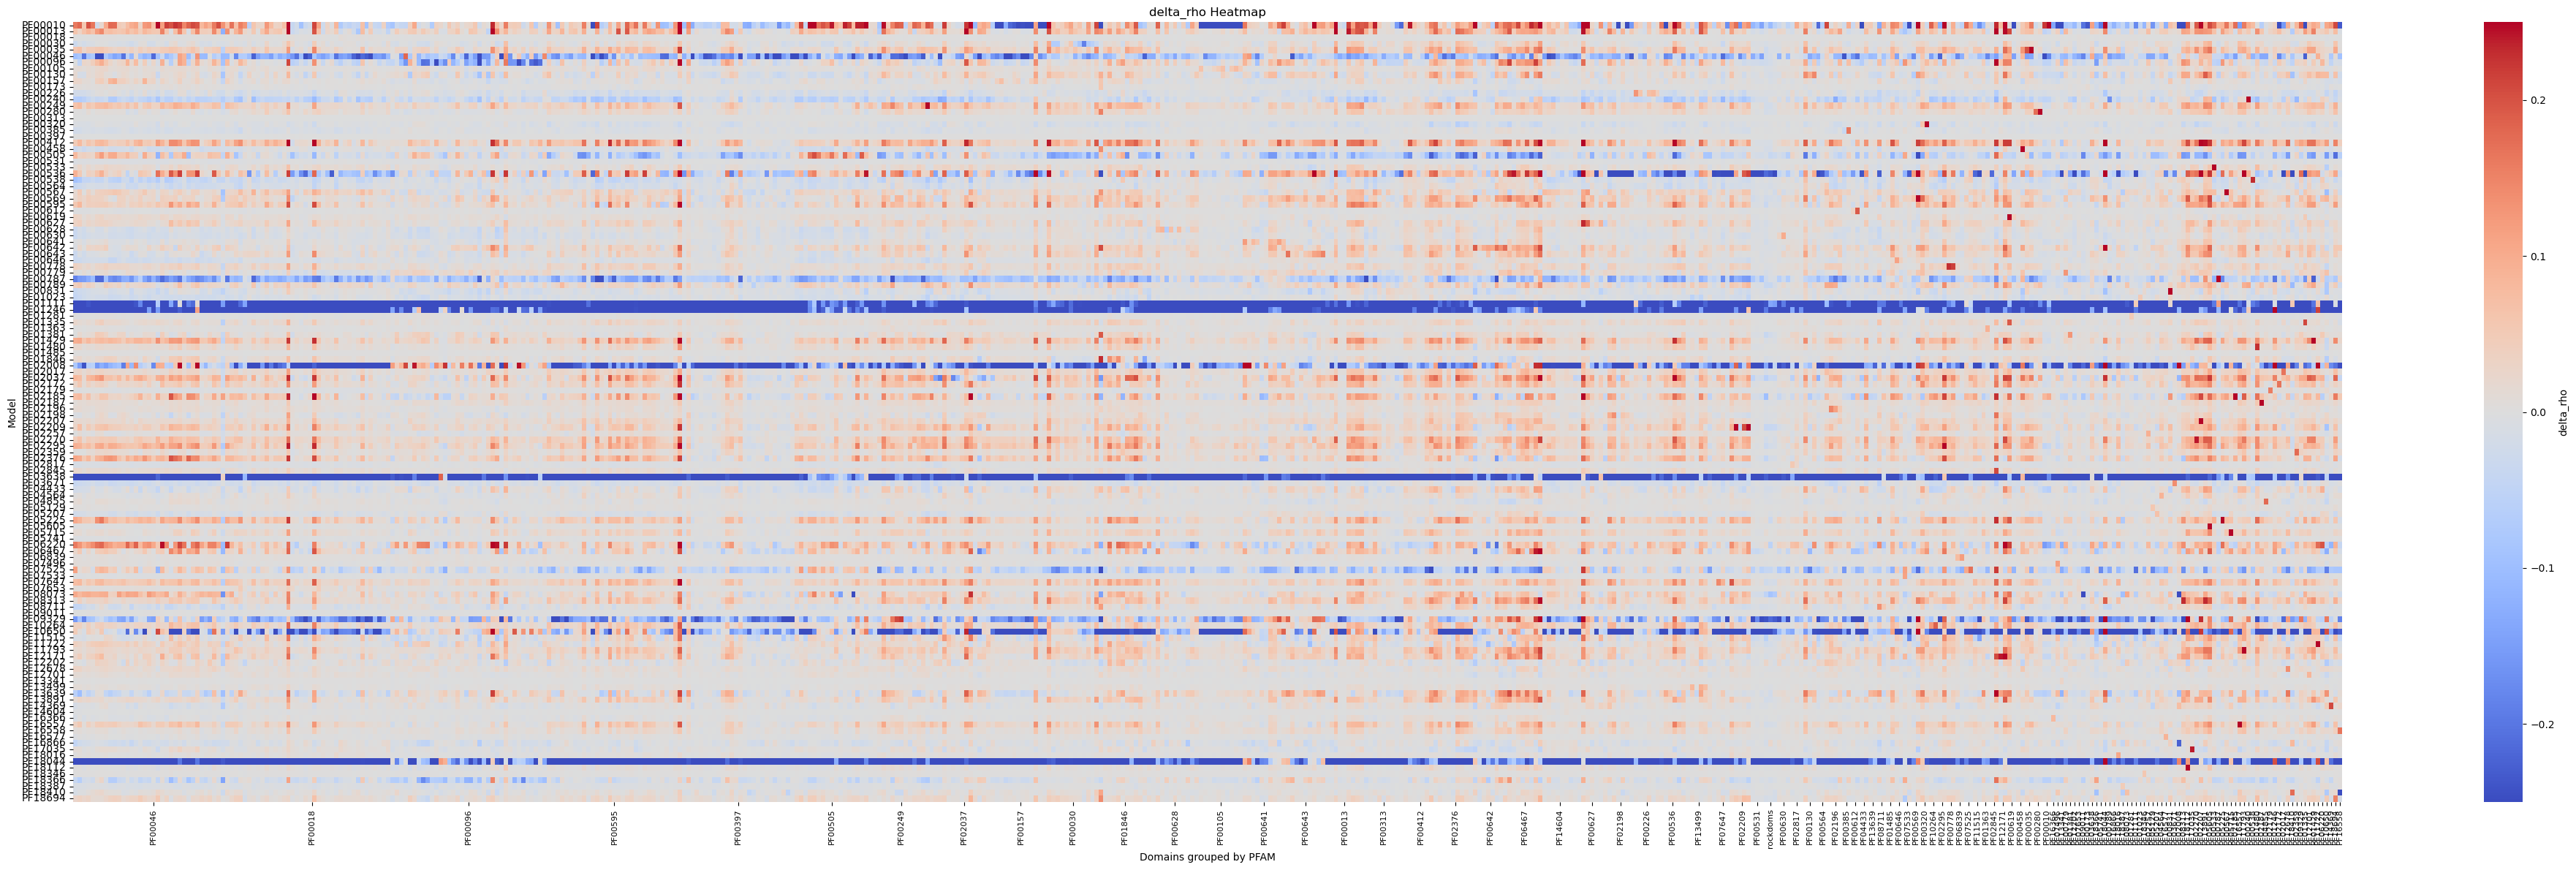

In [22]:
# -----------------------------
# Keep PFAMs ordered by size
# -----------------------------
pfam_order = (
    corr_df['pfam']
    .value_counts()
    .index
)

# Apply categorical ordering
plot_df = corr_df.copy()

plot_df['pfam'] = pd.Categorical(
    plot_df['pfam'],
    categories=pfam_order,
    ordered=True
)

# Sort domains within PFAM
plot_df = plot_df.sort_values(
    ['pfam', 'domain_id']
)

# Ordered domain list
domain_order = plot_df['domain_id'].drop_duplicates().tolist()

# -----------------------------
# Pivot into heatmap matrix
# -----------------------------
heatmap_df = plot_df.pivot_table(
    index='model',
    columns='domain_id',
    values='delta_rho'
)

# Reorder columns
heatmap_df = heatmap_df[domain_order]

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(40, 12))

sns.heatmap(
    heatmap_df,
    cmap='coolwarm',
    center=0,
    vmin=-0.25,
    vmax=0.25,
    xticklabels=False,
    yticklabels=True,
    cbar_kws={'label': 'delta_rho'},
    ax=ax
)

# -----------------------------
# Center PFAM labels
# -----------------------------
tick_positions = []
tick_labels = []

start = 0

for pfam in pfam_order:

    domains_in_pfam = (
        plot_df.loc[plot_df['pfam'] == pfam, 'domain_id']
        .drop_duplicates()
    )

    count = len(domains_in_pfam)

    center = start + count / 2

    tick_positions.append(center)
    tick_labels.append(pfam)

    start += count

ax.set_xticks(tick_positions)
ax.set_xticklabels(
    tick_labels,
    rotation=90,
    fontsize=8
)

ax.set_xlabel("Domains grouped by PFAM")
ax.set_ylabel("Model")
ax.set_title("delta_rho Heatmap")

plt.tight_layout()
plt.show()

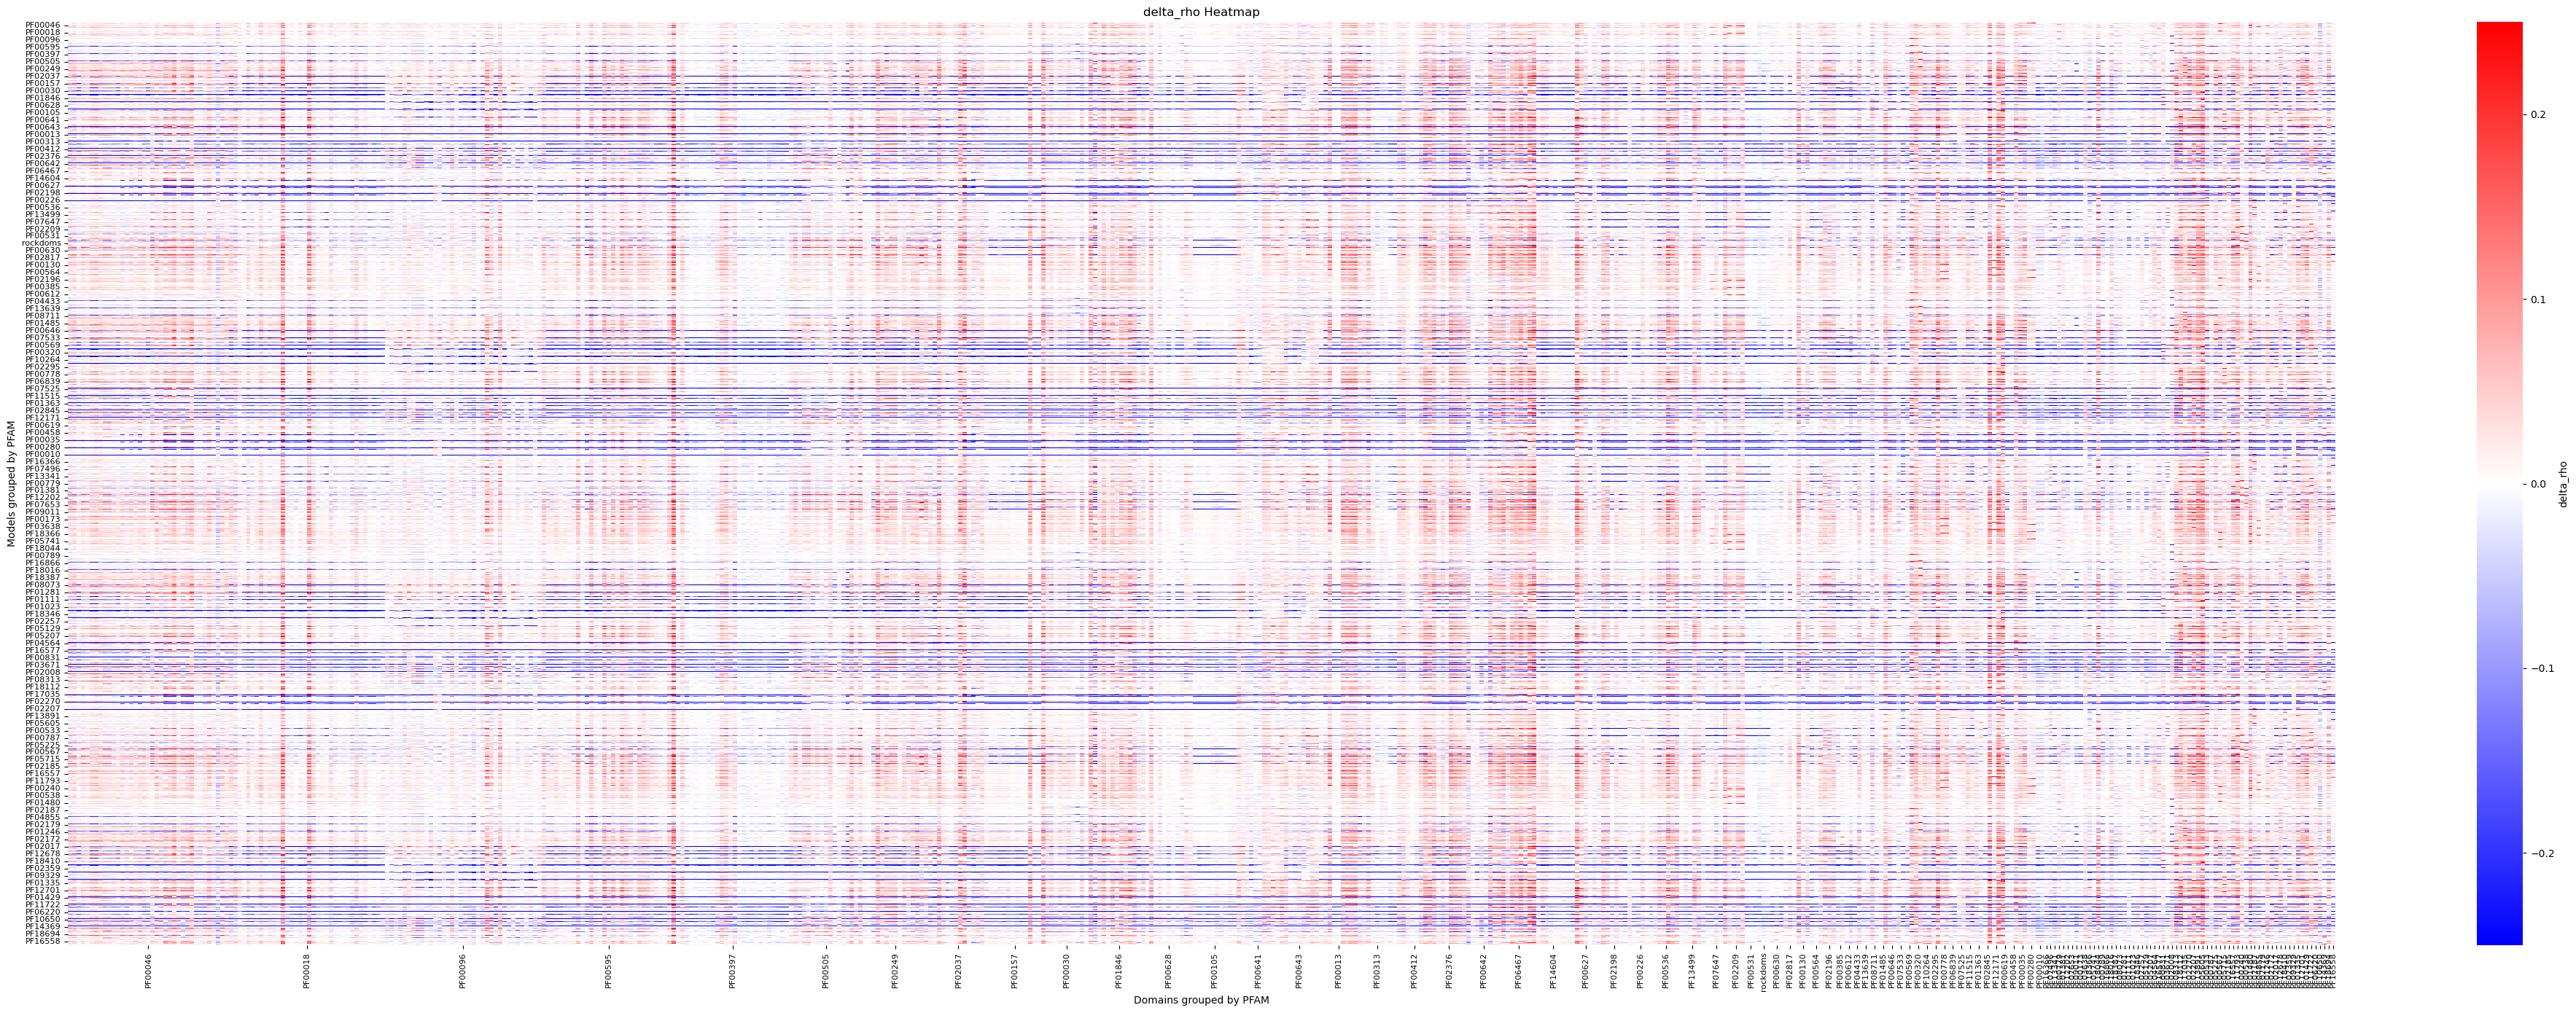

In [24]:
# -----------------------------
# PFAM order by number of domains
# -----------------------------
pfam_order = (
    corr_df['pfam']
    .value_counts()
    .index
)

plot_df = corr_df.copy()

plot_df['pfam'] = pd.Categorical(
    plot_df['pfam'],
    categories=pfam_order,
    ordered=True
)

# -----------------------------
# Order domain_ids on x-axis
# -----------------------------
plot_df = plot_df.sort_values(
    ['pfam', 'domain_id']
)

domain_order = (
    plot_df['domain_id']
    .drop_duplicates()
    .tolist()
)

# -----------------------------
# Map each model -> PFAM
# -----------------------------
model_pfam = (
    plot_df[['model', 'pfam']]
    .drop_duplicates()
)

# Order models by PFAM order
model_pfam['pfam'] = pd.Categorical(
    model_pfam['pfam'],
    categories=pfam_order,
    ordered=True
)

model_pfam = model_pfam.sort_values(['pfam', 'model'])

model_order = model_pfam['model'].tolist()

# -----------------------------
# Pivot heatmap matrix
# -----------------------------
heatmap_df = plot_df.pivot_table(
    index='model',
    columns='domain_id',
    values='delta_rho'
)

# Reorder rows/columns
heatmap_df = heatmap_df.loc[model_order, domain_order]

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(40, 14))

# sns.heatmap(
#     heatmap_df,
#     cmap='coolwarm',
#     center=0,
#     vmin=-0.25,
#     vmax=0.25,
#     xticklabels=False,
#     yticklabels=True,
#     cbar_kws={'label': 'delta_rho'},
#     ax=ax
# )
sns.heatmap(
    heatmap_df,
    cmap='bwr',
    center=0,
    vmin=-0.25,
    vmax=0.25,
    xticklabels=False,
    yticklabels=True,
    cbar_kws={'label': 'delta_rho'},
    ax=ax
)

# -----------------------------
# Center PFAM labels on x-axis
# -----------------------------
x_tick_positions = []
x_tick_labels = []

start = 0

for pfam in pfam_order:

    count = (
        plot_df.loc[plot_df['pfam'] == pfam, 'domain_id']
        .drop_duplicates()
        .shape[0]
    )

    center = start + count / 2

    x_tick_positions.append(center)
    x_tick_labels.append(pfam)

    start += count

ax.set_xticks(x_tick_positions)
ax.set_xticklabels(
    x_tick_labels,
    rotation=90,
    fontsize=8
)

# -----------------------------
# Center PFAM labels on y-axis
# -----------------------------
y_tick_positions = []
y_tick_labels = []

start = 0

for pfam in pfam_order:

    count = (
        model_pfam.loc[model_pfam['pfam'] == pfam, 'model']
        .shape[0]
    )

    center = start + count / 2

    y_tick_positions.append(center)
    y_tick_labels.append(pfam)

    start += count

ax.set_yticks(y_tick_positions)
ax.set_yticklabels(
    y_tick_labels,
    fontsize=8
)

ax.set_xlabel("Domains grouped by PFAM")
ax.set_ylabel("Models grouped by PFAM")
ax.set_title("delta_rho Heatmap")

plt.tight_layout()
plt.show()

In [25]:
corr_df.columns

Index(['model', 'domain_id', 'uniprot_id', 'in_pfam_train', 'n', 'rho_base',
       'p_base', 'rho_ft', 'p_ft', 'delta_rho', 'pfam'],
      dtype='object')

In [27]:
filename = "ESM2_ft_all_sp_df.csv.gz"

bucket_name = GCS_BUCKET
blob_path = "ESM2/ft_all_doms_run2/global_finetune/ESM2_ft_all_sp_df.csv.gz"

# Download from GCS into memory
client = storage.Client()
bucket = client.bucket(bucket_name)
blob = bucket.blob(blob_path)

buffer = io.BytesIO()
blob.download_to_file(buffer)

buffer.seek(0)

# Load directly into dataframe
corr_all_df = pd.read_csv(buffer, compression="gzip")

print(corr_all_df.shape)
corr_all_df.head()

(522, 9)


,domain_id,uniprot_id,n,rho_base,p_base,rho_ft,p_ft,delta_rho,pfam
0,Q9Y6N9_PF00595_207,Q9Y6N9,1255,0.378841,4.165029e-44,0.626113,1.456364e-137,0.247273,PF00595
1,P20936_PF00018_281,P20936,1158,0.422455,2.486852e-51,0.666934,6.875281e-150,0.244478,PF00018
2,Q86VP1_PF18112_729,Q86VP1,494,0.299746,1.029321e-11,0.531721,2.119634e-37,0.231975,PF18112
3,P22681_PF00627_854,P22681,850,0.235321,3.693812e-12,0.457588,3.250431e-45,0.222268,PF00627
4,Q9P0J7_PF05605_76,Q9P0J7,1093,0.303563,9.848891e-25,0.520061,9.076428e-77,0.216498,PF05605


In [30]:
print(corr_all_df.columns)
print(corr_df.columns)

Index(['domain_id', 'uniprot_id', 'n', 'rho_base', 'p_base', 'rho_ft', 'p_ft',
       'delta_rho', 'pfam'],
      dtype='object')
Index(['model', 'domain_id', 'uniprot_id', 'in_pfam_train', 'n', 'rho_base',
       'p_base', 'rho_ft', 'p_ft', 'delta_rho', 'pfam'],
      dtype='object')


In [31]:
corr_all_df['in_pfam_train'] = None

In [32]:
corr_all_df['model'] = 'all_pfams'

In [37]:
corr_combined_df = pd.concat([corr_df, corr_all_df])

In [55]:
corr_combined_df.tail()

,model,domain_id,uniprot_id,in_pfam_train,n,rho_base,p_base,rho_ft,p_ft,delta_rho,pfam
517,all_pfams,P35712_PF00505_622,P35712,None,1251,0.231413,1.136879e-16,0.142435,4.222672e-07,-0.088978,PF00505
518,all_pfams,P19878_PF00564_353,P19878,None,1213,0.469809,1.280882e-67,0.376195,4.524484e-42,-0.093614,PF00564
519,all_pfams,P48431_PF00505_42,P48431,None,1232,0.266543,1.751323e-21,0.164364,6.521899e-09,-0.102179,PF00505
520,all_pfams,Q06945_PF00505_60,Q06945,None,1207,0.326461,2.272511e-31,0.223718,3.714482e-15,-0.102744,PF00505
521,all_pfams,P35711_PF00505_557,P35711,None,1158,0.260646,1.944839e-19,0.134941,4.063460e-06,-0.125704,PF00505


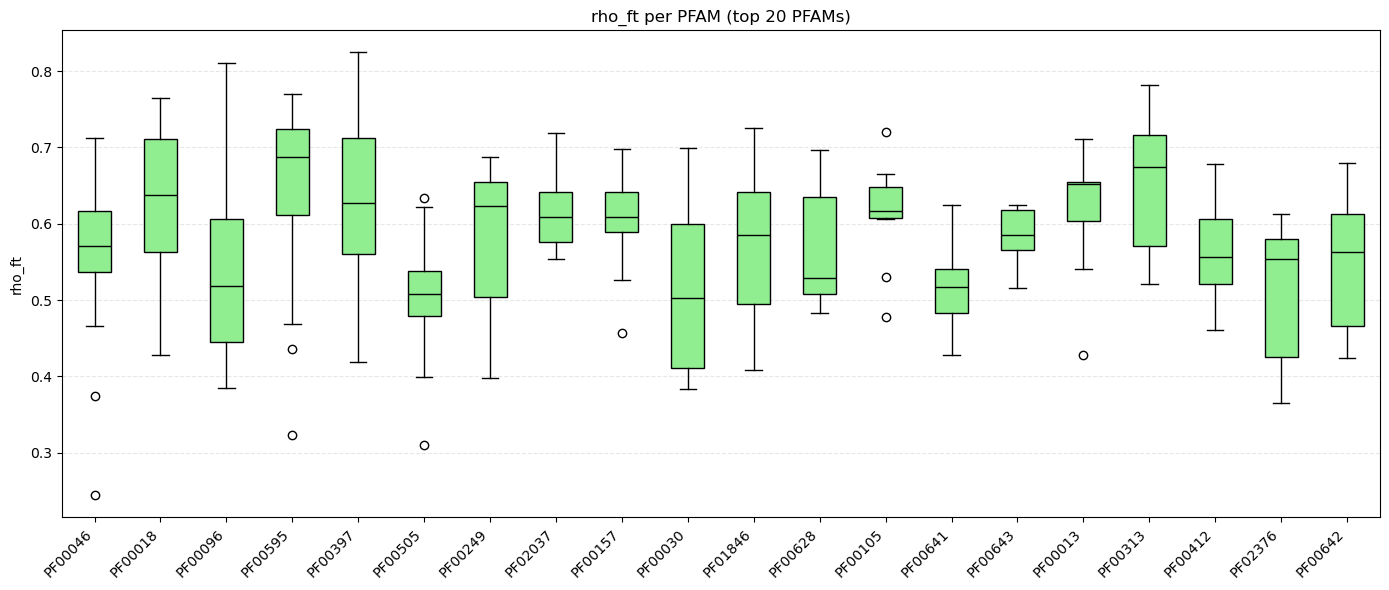

In [54]:
# -----------------------------
# Step 1: top 20 PFAMs by size
# -----------------------------
pfam_counts = corr_df['pfam'].value_counts()
top_pfams = pfam_counts.head(20).index

df = corr_df.loc[corr_df['pfam'].isin(top_pfams)].copy()

# -----------------------------
# Step 2: ensure no duplicate domain confusion
# -----------------------------
df = df.drop_duplicates(subset=['domain_id', 'pfam'])

# -----------------------------
# Step 3: build strictly PFAM-grouped values
# -----------------------------
data = [
    df.loc[df['pfam'] == pfam, 'rho_ft'].values
    for pfam in top_pfams
]

# -----------------------------
# Step 4: plot
# -----------------------------
fig, ax = plt.subplots(figsize=(14, 6))

positions = np.arange(len(top_pfams))

ax.boxplot(
    data,
    positions=positions,
    patch_artist=True,
    boxprops=dict(facecolor='lightgreen'),
    medianprops=dict(color='black')
)

ax.set_xticks(positions)
ax.set_xticklabels(top_pfams, rotation=45, ha='right')

ax.set_ylabel("rho_ft")
ax.set_title("rho_ft per PFAM (top 20 PFAMs)")

ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

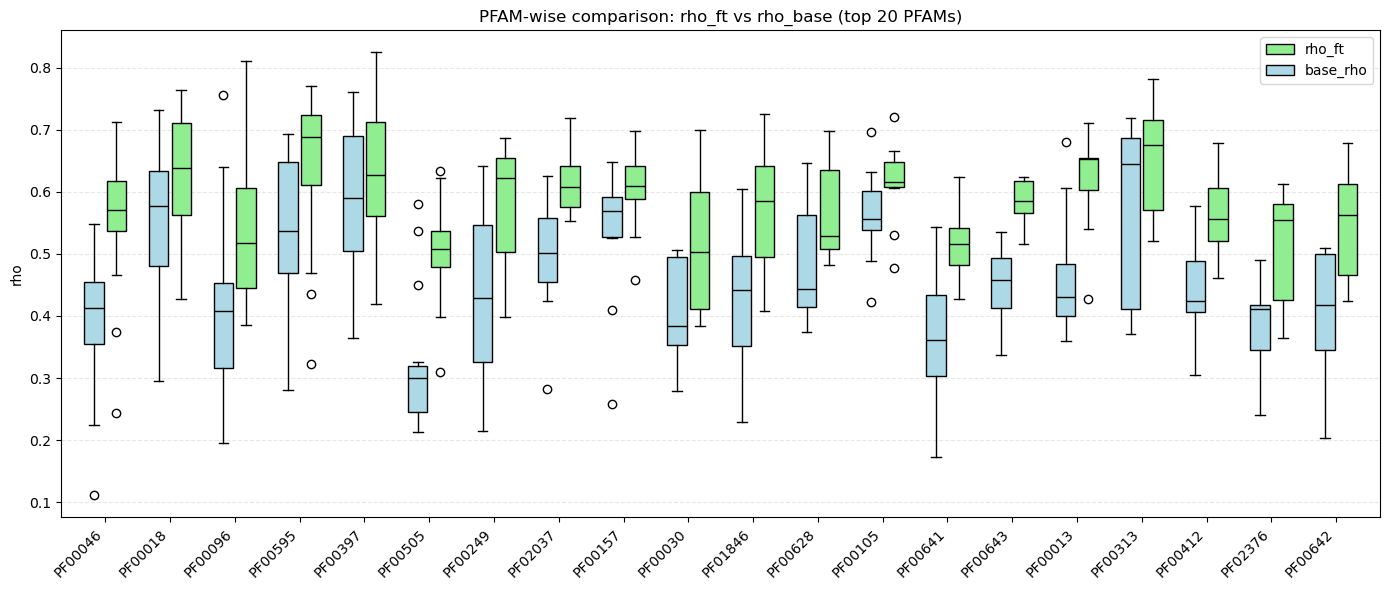

In [61]:
# -----------------------------
# Step 1: top 20 PFAMs by size
# -----------------------------
pfam_counts = corr_df['pfam'].value_counts()
top_pfams = pfam_counts.head(20).index

df = corr_df.loc[corr_df['pfam'].isin(top_pfams)].copy()

# optional safety
df = df.drop_duplicates(subset=['domain_id', 'pfam'])

# -----------------------------
# Step 2: build grouped data
# -----------------------------
ft_data = [
    df.loc[df['pfam'] == pfam, 'rho_ft'].values
    for pfam in top_pfams
]

base_data = [
    df.loc[df['pfam'] == pfam, 'rho_base'].values
    for pfam in top_pfams
]

# -----------------------------
# Step 3: plot side-by-side boxplots
# -----------------------------
fig, ax = plt.subplots(figsize=(14, 6))

positions = np.arange(len(top_pfams))
width = 0.35

# FT boxplots (shift left)
ax.boxplot(
    ft_data,
    positions=positions + width/2,
    widths=0.3,
    patch_artist=True,
    boxprops=dict(facecolor='lightgreen'),
    medianprops=dict(color='black')
)

# Base boxplots (shift right)
ax.boxplot(
    base_data,
    positions=positions - width/2,
    widths=0.3,
    patch_artist=True,
    boxprops=dict(facecolor='lightblue'),
    medianprops=dict(color='black')
)

# -----------------------------
# Formatting
# -----------------------------
ax.set_xticks(positions)
ax.set_xticklabels(top_pfams, rotation=45, ha='right')

ax.set_ylabel("rho")
ax.set_title("PFAM-wise comparison: rho_ft vs rho_base (top 20 PFAMs)")

legend_handles = [
    Patch(facecolor='lightgreen', edgecolor='black', label='rho_ft'),
    Patch(facecolor='lightblue', edgecolor='black', label='base_rho')
]

ax.legend(handles=legend_handles, loc="upper right")

ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# -----------------------------
# Step 1: compute delta_rho
# -----------------------------
corr_df = corr_df.copy()
corr_df['delta_rho'] = corr_df['rho_ft'] - corr_df['rho_base']

# -----------------------------
# Step 2: top 20 PFAMs by mean delta_rho
# -----------------------------
pfam_delta = (
    corr_df.groupby('pfam')['delta_rho']
    .mean()
    .sort_values(ascending=False)
)

top_pfams = pfam_delta.head(20).index

# Filter dataframe
df = corr_df.loc[corr_df['pfam'].isin(top_pfams)].copy()

# optional safety
df = df.drop_duplicates(subset=['domain_id', 'pfam'])

# -----------------------------
# Step 3: build grouped data
# -----------------------------
ft_data = [
    df.loc[df['pfam'] == pfam, 'rho_ft'].values
    for pfam in top_pfams
]

base_data = [
    df.loc[df['pfam'] == pfam, 'rho_base'].values
    for pfam in top_pfams
]

# -----------------------------
# Step 4: plot side-by-side boxplots
# -----------------------------
fig, ax = plt.subplots(figsize=(16, 6))

positions = np.arange(len(top_pfams))
width = 0.35

# FT boxplots
ax.boxplot(
    ft_data,
    positions=positions + width/2,
    widths=0.3,
    patch_artist=True,
    boxprops=dict(facecolor='lightgreen'),
    medianprops=dict(color='black')
)

# Base boxplots
ax.boxplot(
    base_data,
    positions=positions - width/2,
    widths=0.3,
    patch_artist=True,
    boxprops=dict(facecolor='lightblue'),
    medianprops=dict(color='black')
)

# -----------------------------
# Formatting
# -----------------------------
ax.set_xticks(positions)
ax.set_xticklabels(top_pfams, rotation=45, ha='right')

ax.set_ylabel("rho")
ax.set_title("Top 20 PFAMs by mean delta_rho (rho_ft - rho_base)")

legend_handles = [
    Patch(facecolor='lightgreen', edgecolor='black', label='rho_ft'),
    Patch(facecolor='lightblue', edgecolor='black', label='rho_base')
]

ax.legend(handles=legend_handles, loc="upper right")

ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [63]:
filename = "ESM2_ft_combined_sp_df.csv.gz"

buffer = io.BytesIO()

with gzip.GzipFile(fileobj=buffer, mode="wb") as gz:
    gz.write(
        corr_df.to_csv(index=False).encode("utf-8")
    )

buffer.seek(0)

# Upload directly to GCS
bucket_name = GCS_BUCKET
destination_blob = f"ESM2/{filename}"

client = storage.Client()
bucket = client.bucket(bucket_name)
blob = bucket.blob(destination_blob)

blob.upload_from_file(
    buffer,
    content_type="application/gzip"
)

print(f"Uploaded to gs://{bucket_name}/{destination_blob}")

Uploaded to gs://domainome-data/ESM2/ESM2_ft_combined_sp_df.csv.gz
